In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('flight_data_2018_2024.csv')
df.shape


/tmp/ipykernel_3358/3413235828.py:6: DtypeWarning: Columns (11,13,86,93,94,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('flight_data_2018_2024.csv')


(582425, 120)

## 🧾 Step 2: Check Column Names and Data Types

We will now look at the column names and their data types to understand what kind of preprocessing may be required.


In [126]:
# Remove the column display limit completely
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.reset_option('display')



In [127]:
# View column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(70), int64(23), object(27)
memory usage: 533.2+ MB


In [128]:
df.sample(5)

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
510937,2024,1,1,3,3,2024-01-03,AA,AA,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
85449,2024,1,1,21,7,2024-01-21,WN,WN,19393,WN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
70275,2024,1,1,5,5,2024-01-05,WN,WN,19393,WN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
260102,2024,1,1,10,3,2024-01-10,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
509793,2024,1,1,25,4,2024-01-25,AA,AA,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [143]:
l=[]
for i in df.columns.str.strip():
  l.append(i)
l

['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Marketing_Airline_Network',
 'Operated_or_Branded_Code_Share_Partners',
 'DOT_ID_Marketing_Airline',
 'IATA_Code_Marketing_Airline',
 'Flight_Number_Marketing_Airline',
 'Originally_Scheduled_Code_Share_Airline',
 'DOT_ID_Originally_Scheduled_Code_Share_Airline',
 'IATA_Code_Originally_Scheduled_Code_Share_Airline',
 'Flight_Num_Originally_Scheduled_Code_Share_Airline',
 'Operating_Airline',
 'DOT_ID_Operating_Airline',
 'IATA_Code_Operating_Airline',
 'Tail_Number',
 'Flight_Number_Operating_Airline',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'D

From the output, we can identify:
- Categorical columns: Airline, Origin, Dest, etc.
- Numerical columns: DepDelay, ArrDelay, Distance
- Datetime: FlightDate (to be converted)
Next, we will check for missing values in the dataset.


## 🧹 Step 3: Check for Missing Values

To ensure data quality, we will now inspect the dataset for any missing values across all columns.


In [68]:
# Count of missing values in each column
df.isnull().sum().sort_values(ascending=False)


,0
Div5AirportID,582425
Div5Airport,582425
Div4TailNum,582425
Div4WheelsOff,582425
Div4LongestGTime,582425
...,...
CRSElapsedTime,0
Cancelled,0
DistanceGroup,0
Diverted,0


In [69]:
for i in (df.columns): print(i)

Year
Quarter
Month
DayofMonth
DayOfWeek
FlightDate
Marketing_Airline_Network
Operated_or_Branded_Code_Share_Partners
DOT_ID_Marketing_Airline
IATA_Code_Marketing_Airline
Flight_Number_Marketing_Airline
Originally_Scheduled_Code_Share_Airline
DOT_ID_Originally_Scheduled_Code_Share_Airline
IATA_Code_Originally_Scheduled_Code_Share_Airline
Flight_Num_Originally_Scheduled_Code_Share_Airline
Operating_Airline 
DOT_ID_Operating_Airline
IATA_Code_Operating_Airline
Tail_Number
Flight_Number_Operating_Airline
OriginAirportID
OriginAirportSeqID
OriginCityMarketID
Origin
OriginCityName
OriginState
OriginStateFips
OriginStateName
OriginWac
DestAirportID
DestAirportSeqID
DestCityMarketID
Dest
DestCityName
DestState
DestStateFips
DestStateName
DestWac
CRSDepTime
DepTime
DepDelay
DepDelayMinutes
DepDel15
DepartureDelayGroups
DepTimeBlk
TaxiOut
WheelsOff
WheelsOn
TaxiIn
CRSArrTime
ArrTime
ArrDelay
ArrDelayMinutes
ArrDel15
ArrivalDelayGroups
ArrTimeBlk
Cancelled
CancellationCode
Diverted
CRSElapsedTime

Columns with a high number of missing values may need to be dropped or imputed.  
We will decide on handling them later based on their significance to the analysis.


In [71]:
print(df.shape)
print(df[['Year', 'Month', 'Cancelled', 'DepDelay', 'ArrDelay']].isnull().sum())
print(df[['Year', 'Month', 'Cancelled', 'DepDelay', 'ArrDelay']].head(10))


(582425, 120)
Year             0
Month            0
Cancelled        0
DepDelay     21470
ArrDelay     23710
dtype: int64
   Year  Month  Cancelled  DepDelay  ArrDelay
0  2024      1        0.0      71.0      45.0
1  2024      1        0.0      -1.0      26.0
2  2024      1        0.0      74.0      86.0
3  2024      1        0.0       0.0      25.0
4  2024      1        0.0      33.0      18.0
5  2024      1        0.0      52.0      48.0
6  2024      1        0.0       7.0      11.0
7  2024      1        1.0       NaN       NaN
8  2024      1        0.0     -10.0     -12.0
9  2024      1        0.0      -6.0     -35.0


In [ ]:
# Filter rows with valid (non-null) delay values
#df_clean = df[['Year', 'Month', 'DepDelay', 'ArrDelay', 'Cancelled']].dropna()


In [ ]:
#df_clean = df[['Year', 'Month', 'DepDelay', 'ArrDelay', 'Cancelled']].dropna()
#print("Rows after dropna:", df_clean.shape[0])
#print(df_clean.head(10))


In [ ]:
#print(df_clean.dtypes)


## 📅 Step 4: Convert Flight Date to Datetime Format

To perform time-based analysis, we must ensure that the `FlightDate` column is in proper datetime format.


In [72]:
# Convert FlightDate to datetime
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

# Extract year, month, day for analysis
df['Year'] = df['FlightDate'].dt.year
df['Month'] = df['FlightDate'].dt.month
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek


We now have additional columns for `Year`, `Month`, and `DayOfWeek` extracted from `FlightDate`,  
which will be useful for temporal trend analysis.
Next, we will explore delay distributions.


## 📊 Step 5: Distribution of Departure Delays

We will visualize the distribution of departure delays to understand how frequent different levels of delay are.  
This will help us identify outliers and the typical range of delay values.


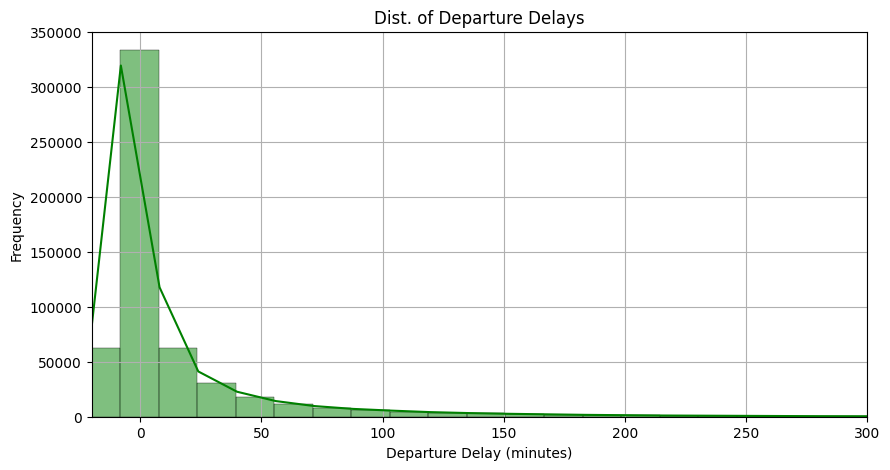

In [73]:
plt.figure(figsize=(10, 5))
sns.histplot(df['DepDelay'], bins=200, kde=True, color='green')
plt.title('Dist. of Departure Delays')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Frequency')
plt.xlim(-20, 300)
plt.grid(True)
plt.show()


## 📊 Step 6: Distribution of Arrival Delays

Similar to departure delays, we will plot the distribution of arrival delays.  
This comparison helps assess whether arrival delays tend to be higher or lower than departure delays.


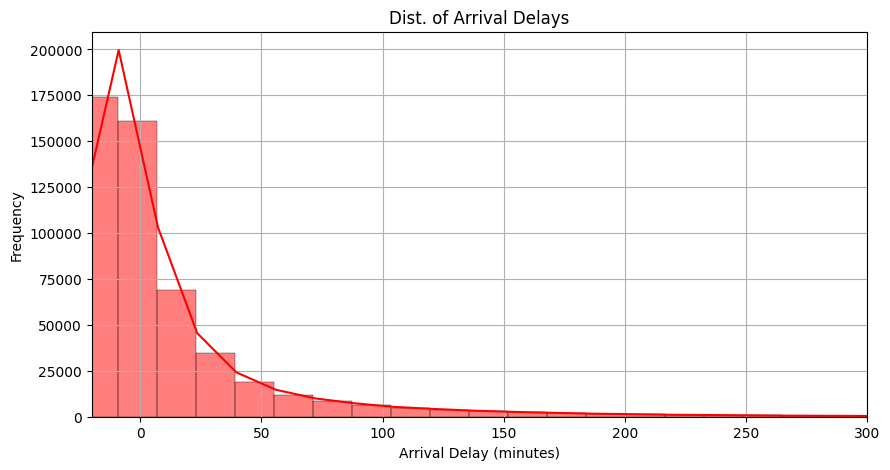

In [74]:
plt.figure(figsize=(10, 5))
sns.histplot(df['ArrDelay'], bins=200, kde=True, color='red')
plt.title('Dist. of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')
plt.xlim(-20, 300)
plt.grid(True)
plt.show()


## 📅 Step 8: Average Delay by Day of the Week

We analyze the average delay by day of the week to detect any weekly patterns,  
such as whether delays increase during weekends or weekdays.


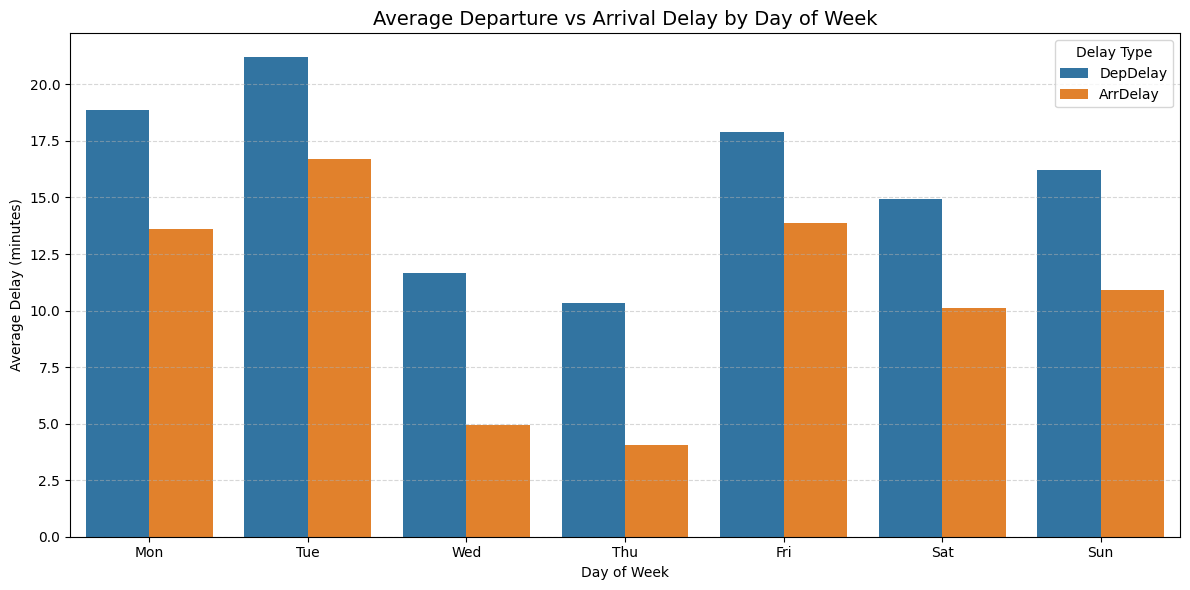

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Average delays by day
dow_delay = (
    df.groupby('DayOfWeek')[['DepDelay', 'ArrDelay']]
      .mean()
      .reset_index()
)

day_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed',
    3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}

dow_delay['DayOfWeek'] = dow_delay['DayOfWeek'].map(day_map)
# Convert to long format
plot_df = dow_delay.melt(
    id_vars='DayOfWeek',
    value_vars=['DepDelay', 'ArrDelay'],
    var_name='DelayType',
    value_name='AvgDelay'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_df,
    x='DayOfWeek',
    y='AvgDelay',
    hue='DelayType'
)

plt.title('Average Departure vs Arrival Delay by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Delay Type')
plt.tight_layout()
plt.show()

## ✈️ Step 9: Top Airlines with Most Average Delay

We calculate the average delay per airline to find which airlines tend to be the most delayed on average.


/tmp/ipykernel_3358/2112533495.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ArrDelay', y='Marketing_Airline_Network', data=airline_delay, palette='Reds_r')


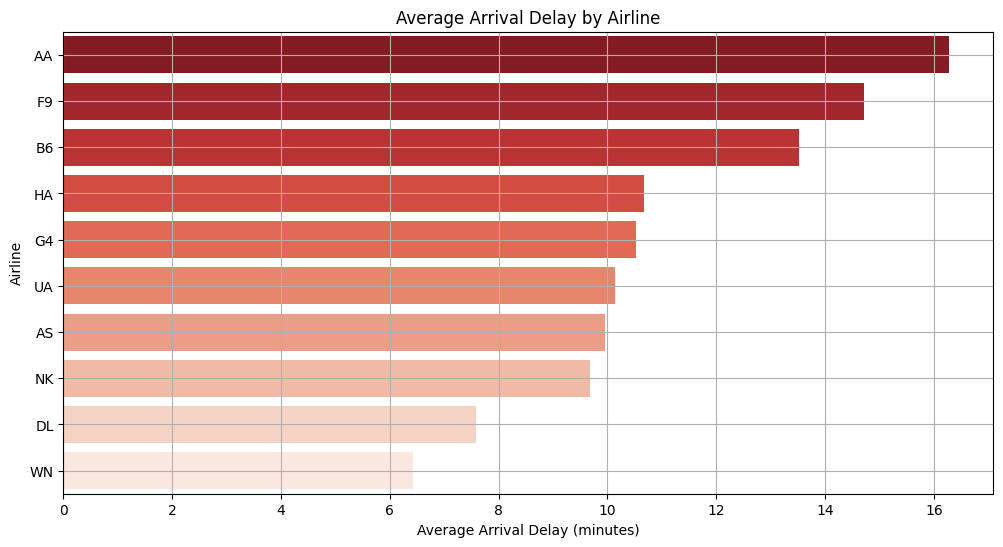

In [82]:
airline_delay = df.groupby('Marketing_Airline_Network')[['DepDelay', 'ArrDelay']].mean().sort_values(by='ArrDelay', ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='ArrDelay', y='Marketing_Airline_Network', data=airline_delay, palette='Reds_r')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🛫 Step 10: Top 10 Origin Airports with Most Average Departure Delay

Now we will rank origin airports by average departure delay.  
This helps identify which airports are bottlenecks or hotspots for delays.


/tmp/ipykernel_3358/2272724746.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DepDelay', y='Origin', data=origin_delay, palette='coolwarm')


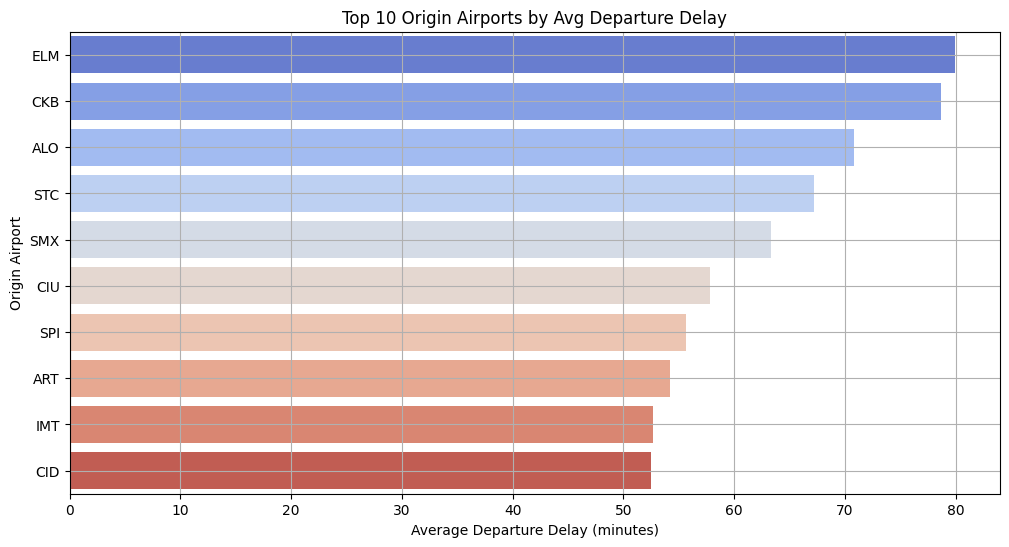

In [83]:
origin_delay = df.groupby('Origin')['DepDelay'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='DepDelay', y='Origin', data=origin_delay, palette='coolwarm')
plt.title('Top 10 Origin Airports by Avg Departure Delay')
plt.xlabel('Average Departure Delay (minutes)')
plt.ylabel('Origin Airport')
plt.grid(True)
plt.show()


## 🛬 Step 11: Top 10 Destination Airports with Most Arrival Delays

We identify the top 10 destination airports with the highest average arrival delays.  
This reveals which airports tend to receive the most delayed flights.


/tmp/ipykernel_3358/3685123130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ArrDelay', y='Dest', data=dest_delay, palette='magma')


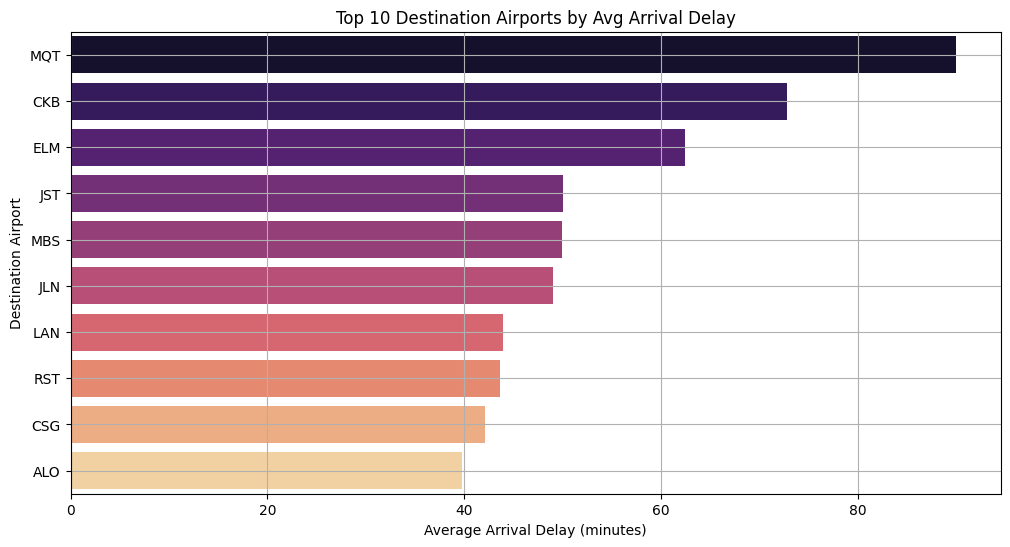

In [84]:
dest_delay = df.groupby('Dest')['ArrDelay'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='ArrDelay', y='Dest', data=dest_delay, palette='magma')
plt.title('Top 10 Destination Airports by Avg Arrival Delay')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Destination Airport')
plt.grid(True)
plt.show()


## 🧭 Step 12: Average Delay by Month and Airline

We create a pivot table to visualize how average delays vary across months and airlines.  
A heatmap helps reveal seasonality patterns for each carrier.


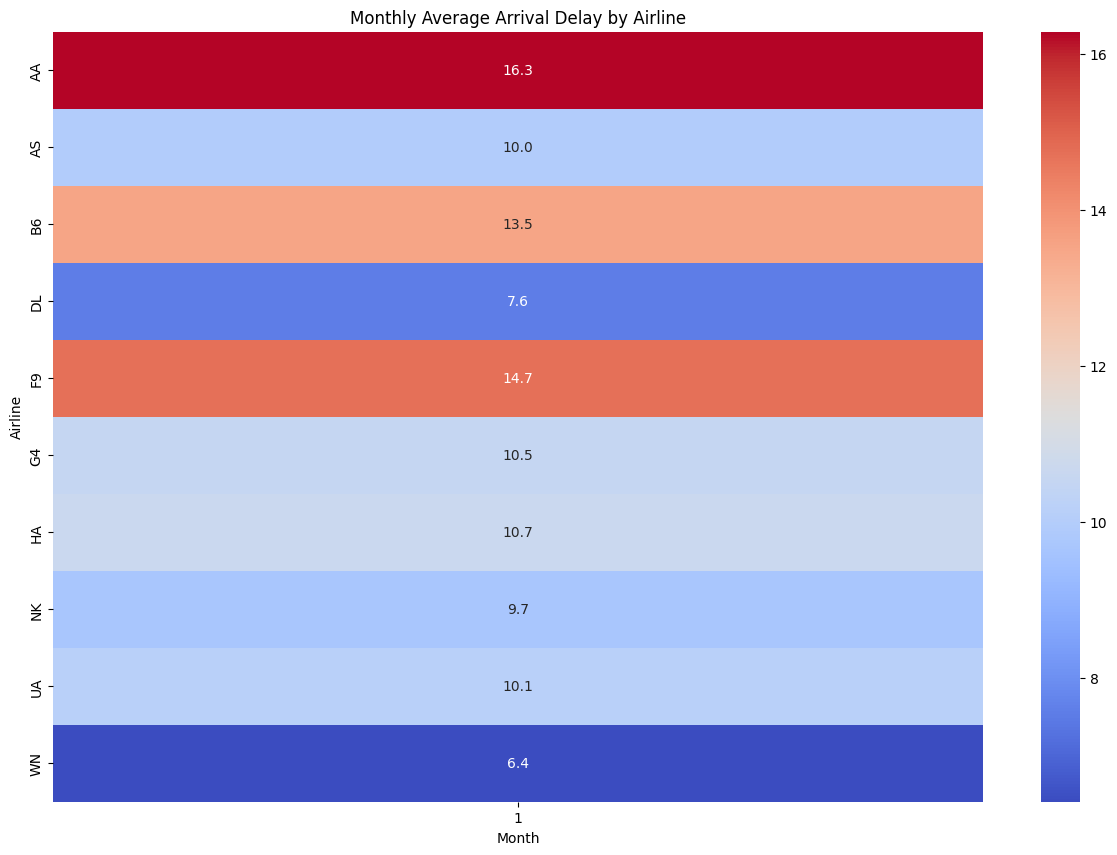

In [85]:
pivot_delay = df.pivot_table(index='Marketing_Airline_Network', columns='Month', values='ArrDelay', aggfunc='mean')

plt.figure(figsize=(15, 10))
sns.heatmap(pivot_delay, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Monthly Average Arrival Delay by Airline')
plt.xlabel('Month')
plt.ylabel('Airline')
plt.show()


## 🔁 Step 13: Compare Departure and Arrival Delays

This comparison shows how closely departure delays translate into arrival delays.  
A strong correlation might indicate consistent delay propagation.


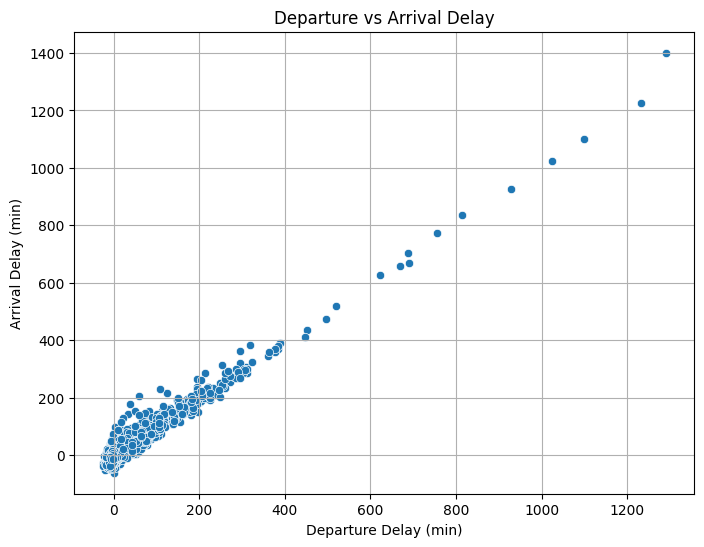

In [86]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='DepDelay', y='ArrDelay', data=df.sample(5000))
plt.title('Departure vs Arrival Delay')
plt.xlabel('Departure Delay (min)')
plt.ylabel('Arrival Delay (min)')
plt.grid(True)
plt.show()


## 🛬 Step 14: Arrival Delay by Day of the Week

We examine the average arrival delay for each weekday to explore behavioral patterns across the week.


/tmp/ipykernel_3358/721716073.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dow_arrival, x='DayOfWeek', y='ArrDelay', palette='Blues_d')


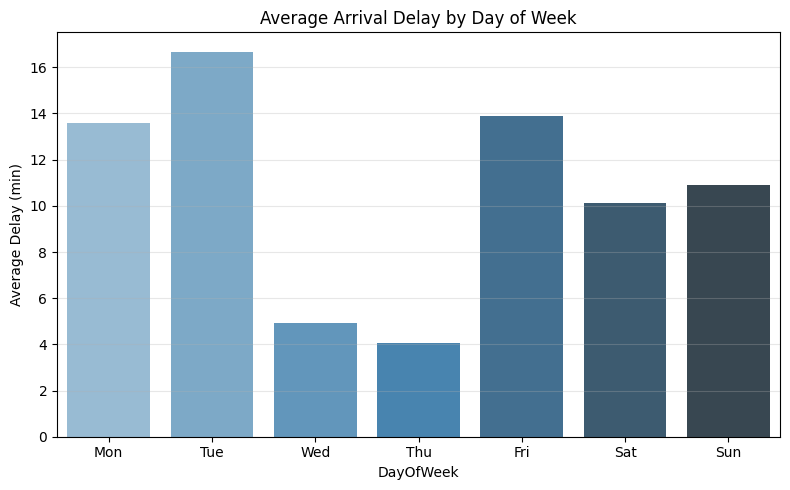

In [88]:
dow_arrival = df.groupby('DayOfWeek')['ArrDelay'].mean().reset_index()
dow_arrival['DayOfWeek'] = dow_arrival['DayOfWeek'].map(day_map)

plt.figure(figsize=(8,5))
sns.barplot(data=dow_arrival, x='DayOfWeek', y='ArrDelay', palette='Blues_d')

plt.title('Average Arrival Delay by Day of Week')
plt.ylabel('Average Delay (min)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🌐 Step 15: Average Departure Delay by U.S. State

This analysis aggregates departure delays by U.S. states to find regional patterns of delay.


/tmp/ipykernel_3358/364502997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='OriginStateName', x='DepDelay', data=state_delay, palette='viridis')


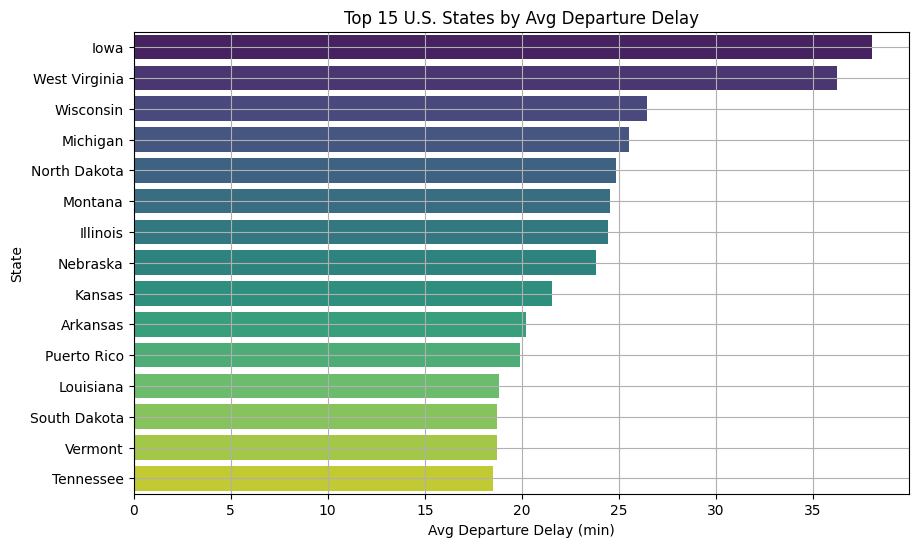

In [89]:
state_delay = df.groupby('OriginStateName')['DepDelay'].mean().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(y='OriginStateName', x='DepDelay', data=state_delay, palette='viridis')
plt.title('Top 15 U.S. States by Avg Departure Delay')
plt.xlabel('Avg Departure Delay (min)')
plt.ylabel('State')
plt.grid(True)
plt.show()


## 🔀 Step 16: Most Delayed City Pairs

We compute average delay for each route (Origin to Destination)  
to find the most problematic air travel paths.


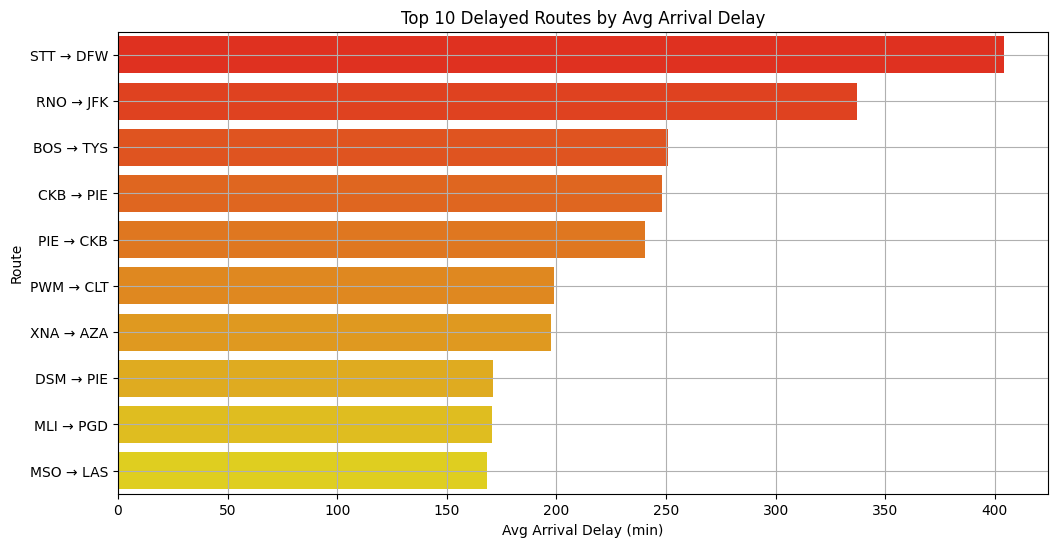

In [ ]:
df['Route'] = df['Origin'] + ' → ' + df['Dest']
route_delay = df.groupby('Route')['ArrDelay'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='ArrDelay', y='Route', data=route_delay, palette='autumn')
plt.title('Top 10 Delayed Routes by Avg Arrival Delay')
plt.xlabel('Avg Arrival Delay (min)')
plt.ylabel('Route')
plt.grid(True)
plt.show()


## 📏 Step 17: Relationship Between Delay and Distance

This plot helps to assess whether longer flights are more likely to be delayed.


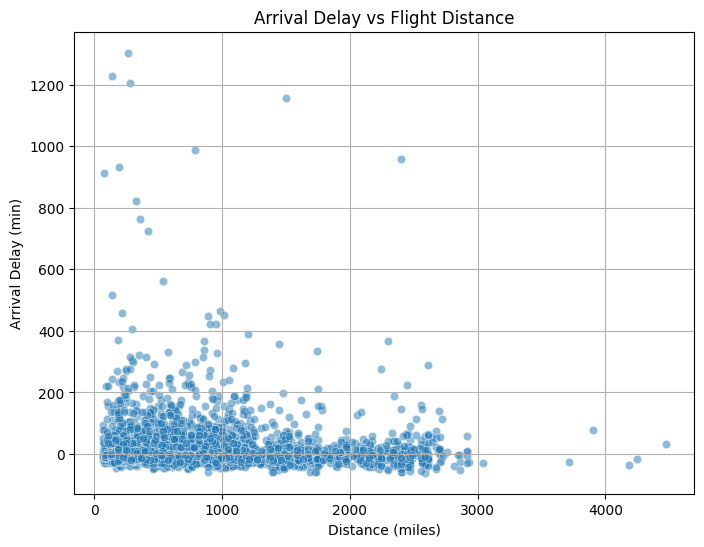

In [90]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Distance', y='ArrDelay', data=df.sample(5000), alpha=0.5)
plt.title('Arrival Delay vs Flight Distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Arrival Delay (min)')
plt.grid(True)
plt.show()


## 🚫 Step 18: Cancellation Rate per Airline

We calculate the cancellation percentage for each airline to determine  
which carriers cancel more of their scheduled flights.


/tmp/ipykernel_3358/2878766952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cancelled', y='Marketing_Airline_Network', data=cancel_rate, palette='Reds')


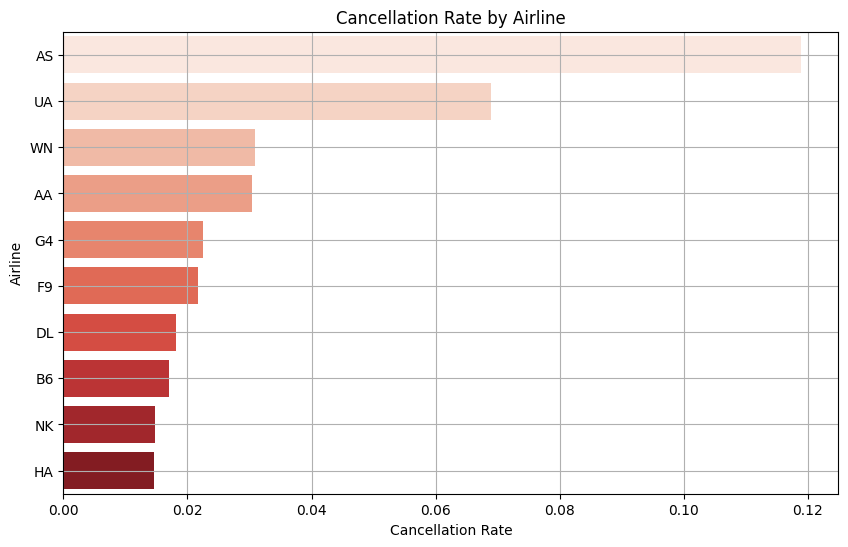

In [91]:
cancel_rate = df.groupby('Marketing_Airline_Network')['Cancelled'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cancelled', y='Marketing_Airline_Network', data=cancel_rate, palette='Reds')
plt.title('Cancellation Rate by Airline')
plt.xlabel('Cancellation Rate')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🕑 Step 19: Average Delay by Scheduled Departure Time Block

Using the `DepTimeBlk` column, we analyze which parts of the day  
are most prone to delays (e.g. early morning vs late night).


/tmp/ipykernel_3358/828946852.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DepDelay', y='DepTimeBlk', data=timeblock_delay, palette='cividis')


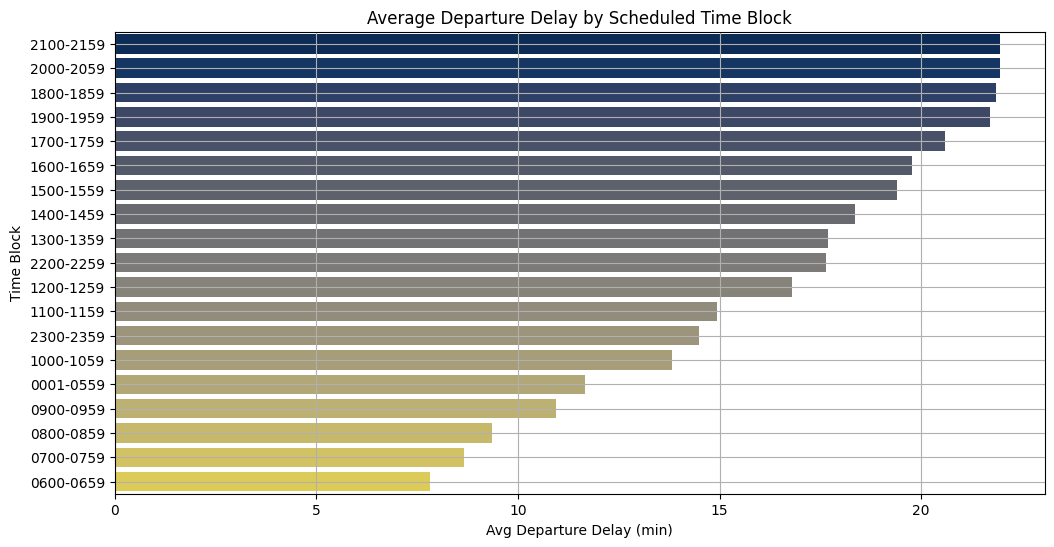

In [92]:
timeblock_delay = df.groupby('DepTimeBlk')['DepDelay'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='DepDelay', y='DepTimeBlk', data=timeblock_delay, palette='cividis')
plt.title('Average Departure Delay by Scheduled Time Block')
plt.xlabel('Avg Departure Delay (min)')
plt.ylabel('Time Block')
plt.grid(True)
plt.show()


## 🔍 Step 20: Delay Distribution by Delay Cause Type

We compare average delay contributions from various sources  
(Carrier, Weather, NAS, Security, Late Aircraft).


/tmp/ipykernel_3358/3944001047.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AverageDelay', y='Cause', data=delay_causes, palette='plasma')


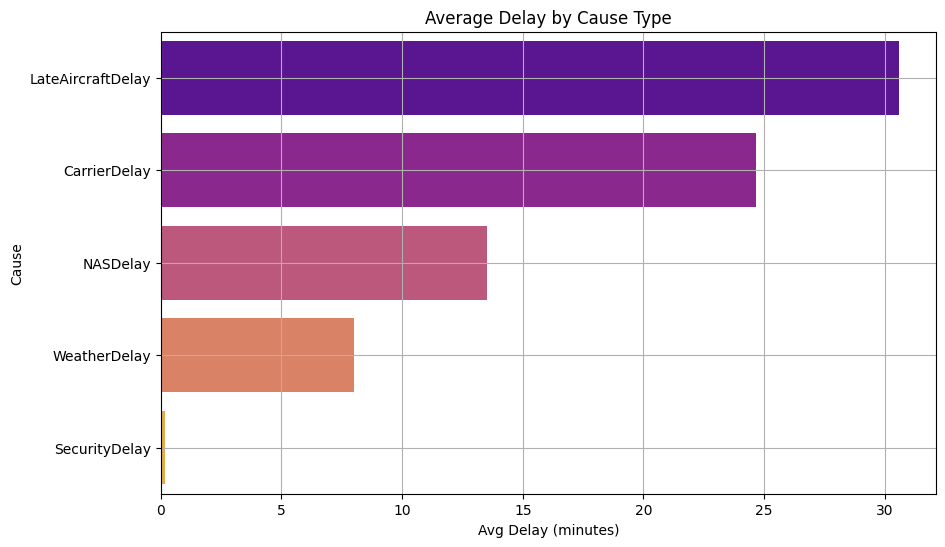

In [93]:
cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
delay_causes = df[cause_cols].mean().sort_values(ascending=False).reset_index()
delay_causes.columns = ['Cause', 'AverageDelay']

plt.figure(figsize=(10, 6))
sns.barplot(x='AverageDelay', y='Cause', data=delay_causes, palette='plasma')
plt.title('Average Delay by Cause Type')
plt.xlabel('Avg Delay (minutes)')
plt.ylabel('Cause')
plt.grid(True)
plt.show()


##21. Average Arrival Delay by Airline (IATA Code)
This analysis groups the flight dataset by each airline's IATA marketing code and computes the average arrival delay for each airline. It then visualizes the result using a horizontal bar chart.

/tmp/ipykernel_3358/3679991935.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ArrDelay', y='IATA_Code_Marketing_Airline', data=airline_delay, palette='Reds_r')


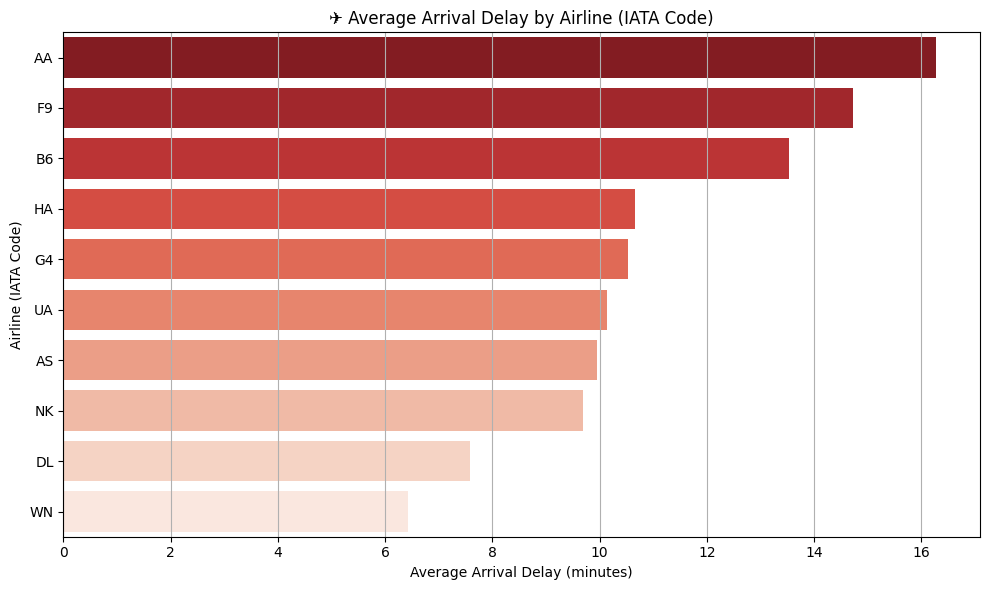

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by IATA code and calculate average arrival delay
airline_delay = df.groupby('IATA_Code_Marketing_Airline')['ArrDelay'].mean().reset_index().sort_values(by='ArrDelay', ascending=False)

# Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(x='ArrDelay', y='IATA_Code_Marketing_Airline', data=airline_delay, palette='Reds_r')
plt.title('✈️ Average Arrival Delay by Airline (IATA Code)')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Airline (IATA Code)')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


## 🧳 Step 22: Average Taxi-Out and Taxi-In Time by Airline

We calculate average taxi times for each airline to assess ground operation efficiency.


/tmp/ipykernel_3358/1885169712.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TaxiOut', y='Marketing_Airline_Network', data=taxi_time, palette='Spectral')


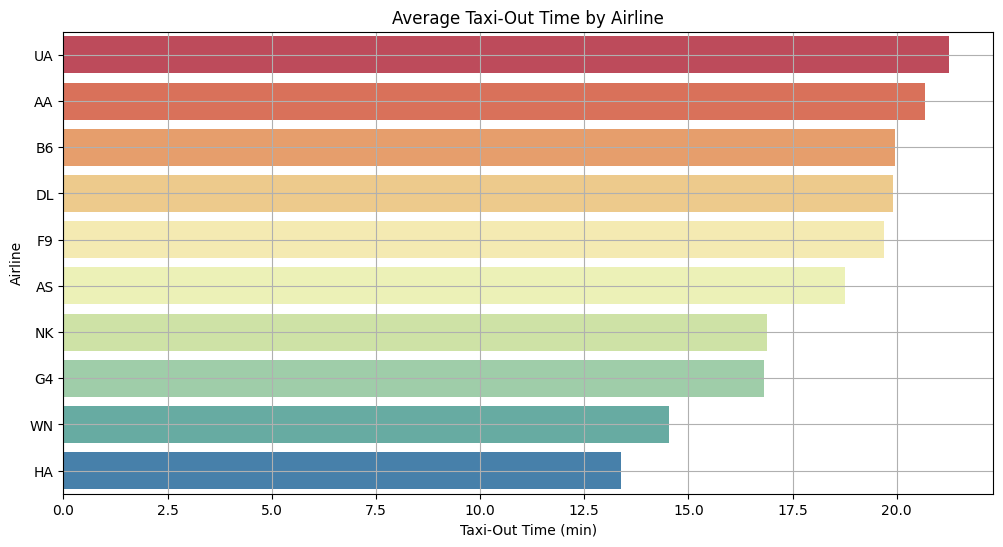

In [95]:
taxi_time = df.groupby('Marketing_Airline_Network')[['TaxiOut', 'TaxiIn']].mean().sort_values(by='TaxiOut', ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='TaxiOut', y='Marketing_Airline_Network', data=taxi_time, palette='Spectral')
plt.title('Average Taxi-Out Time by Airline')
plt.xlabel('Taxi-Out Time (min)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## ✈️ Step 23: Average Air Time by Airline

We examine which airlines typically have longer flight durations,  
which may relate to the type of routes they operate.


/tmp/ipykernel_3358/2864551633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AirTime', y='Marketing_Airline_Network', data=air_time, palette='YlGnBu')


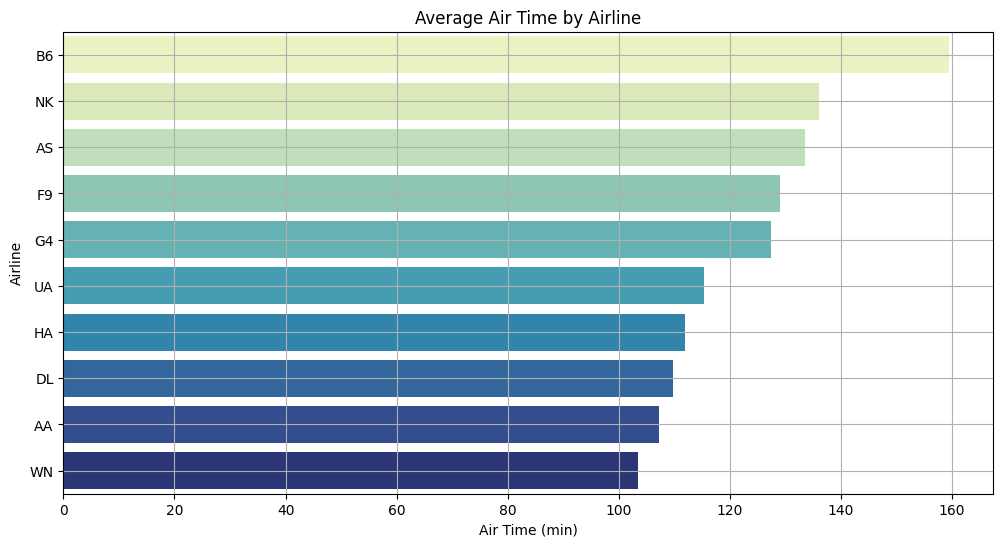

In [96]:
air_time = df.groupby('Marketing_Airline_Network')['AirTime'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='AirTime', y='Marketing_Airline_Network', data=air_time, palette='YlGnBu')
plt.title('Average Air Time by Airline')
plt.xlabel('Air Time (min)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🔁 Step 24: Delay Caused by Late Aircraft

We examine the contribution of previous flights arriving late to current departure delays.


/tmp/ipykernel_3358/1996344355.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LateAircraftDelay', y='Marketing_Airline_Network', data=late_aircraft, palette='OrRd')


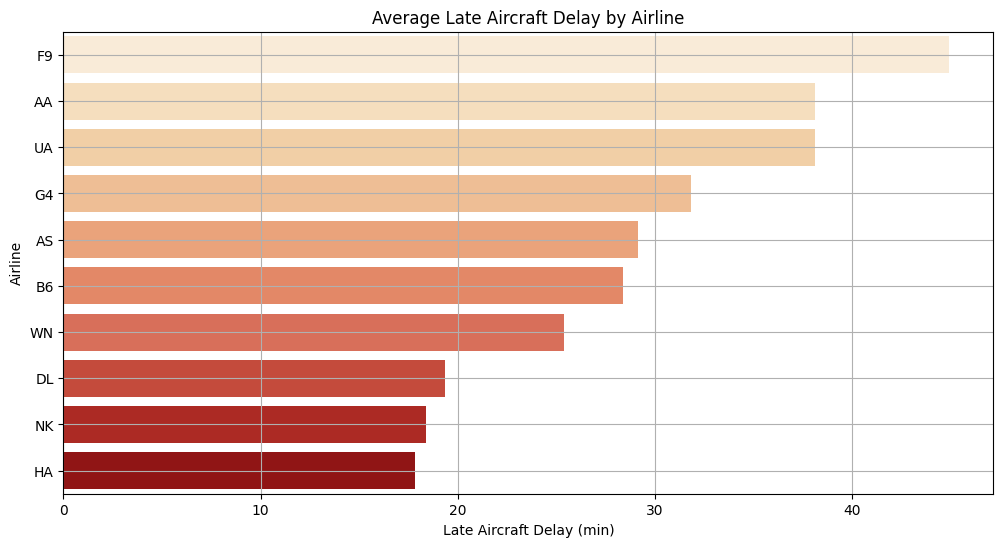

In [97]:
late_aircraft = df.groupby('Marketing_Airline_Network')['LateAircraftDelay'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='LateAircraftDelay', y='Marketing_Airline_Network', data=late_aircraft, palette='OrRd')
plt.title('Average Late Aircraft Delay by Airline')
plt.xlabel('Late Aircraft Delay (min)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## ⚠️ Step 25: Count of Flights Delayed Over 3 Hours

We count how many flights are delayed more than 180 minutes,  
which typically affects regulations and passenger compensation.


/tmp/ipykernel_3358/1571696417.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Airline', data=extreme_count, palette='coolwarm')


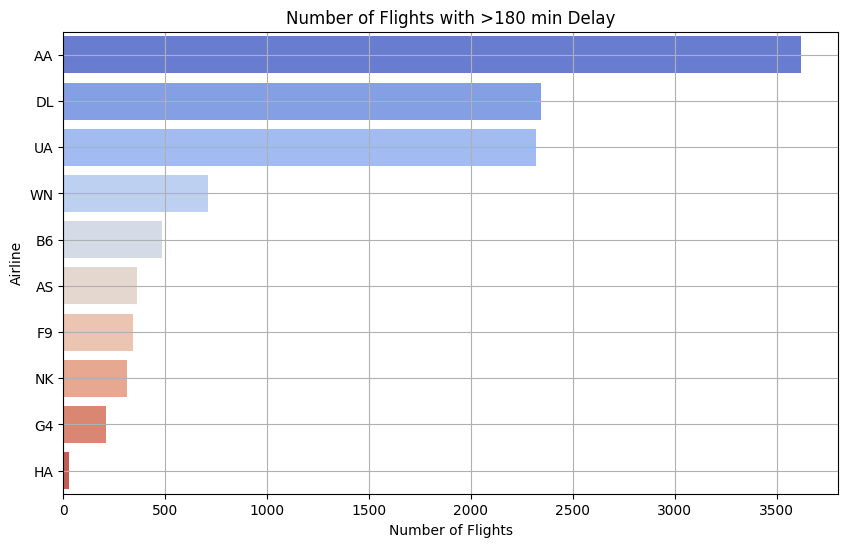

In [98]:
extreme_delay = df[df['ArrDelay'] > 180]
extreme_count = extreme_delay['Marketing_Airline_Network'].value_counts().reset_index()
extreme_count.columns = ['Airline', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Airline', data=extreme_count, palette='coolwarm')
plt.title('Number of Flights with >180 min Delay')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')
plt.grid(True)
plt.show()


## 🔗 Step 26: Correlation Matrix of Delay Variables

We generate a correlation matrix to understand the relationships  
between different delay-related numerical columns.


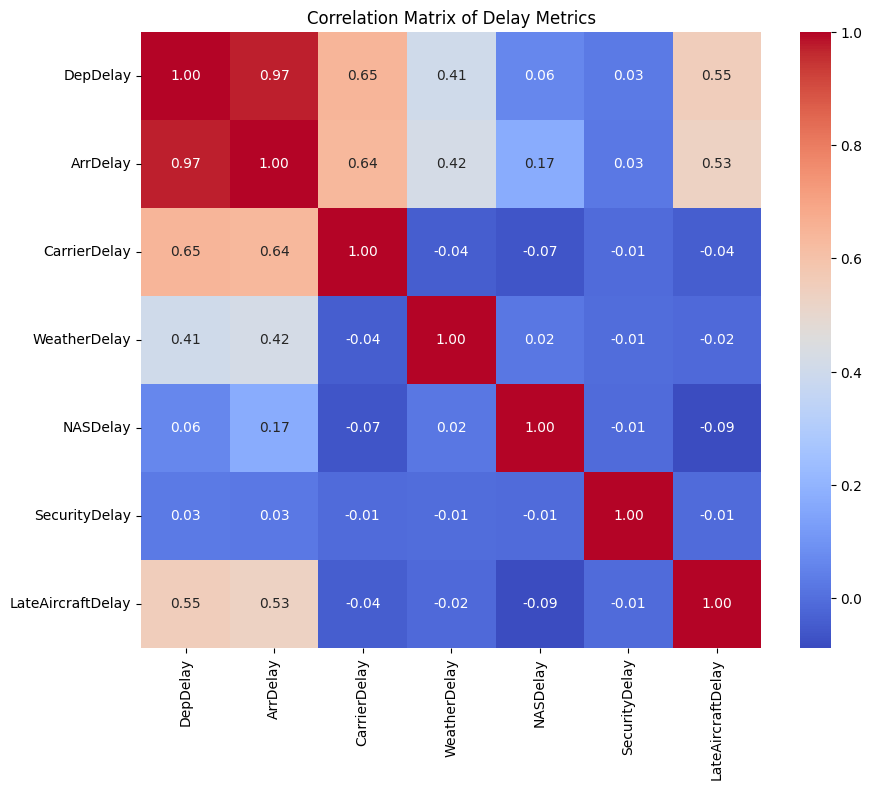

In [99]:
delay_corr = df[['DepDelay', 'ArrDelay', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(delay_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Delay Metrics')
plt.show()


## 🏙️ Step 27: Most Active Origin Airports by Flight Count

We list the origin airports with the highest number of scheduled flights.


/tmp/ipykernel_3358/796178256.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FlightCount', y='Origin', data=top_origins, palette='Set2')


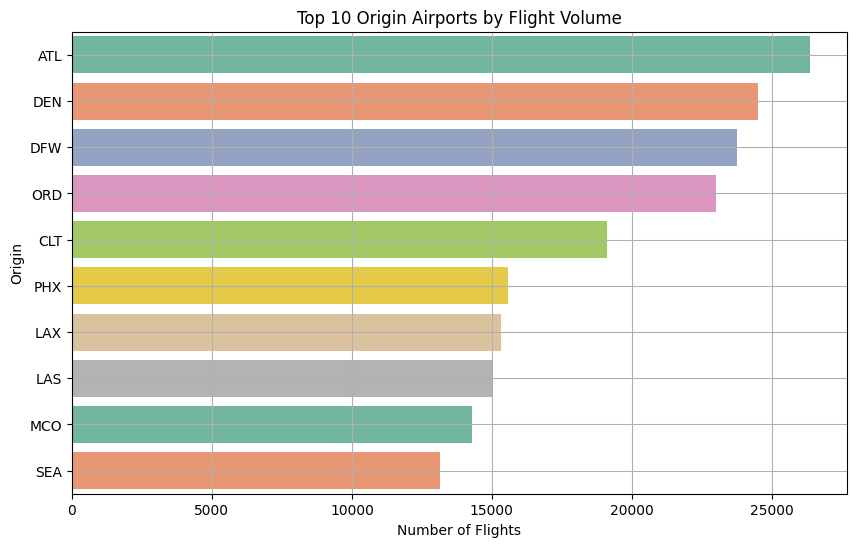

In [100]:
top_origins = df['Origin'].value_counts().head(10).reset_index()
top_origins.columns = ['Origin', 'FlightCount']

plt.figure(figsize=(10, 6))
sns.barplot(x='FlightCount', y='Origin', data=top_origins, palette='Set2')
plt.title('Top 10 Origin Airports by Flight Volume')
plt.xlabel('Number of Flights')
plt.ylabel('Origin')
plt.grid(True)
plt.show()


## 🛬 Step 28: Most Active Destination Airports by Flight Count

We list the top destination airports based on total incoming flights.


/tmp/ipykernel_3358/2662356458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FlightCount', y='Dest', data=top_dests, palette='Set1')


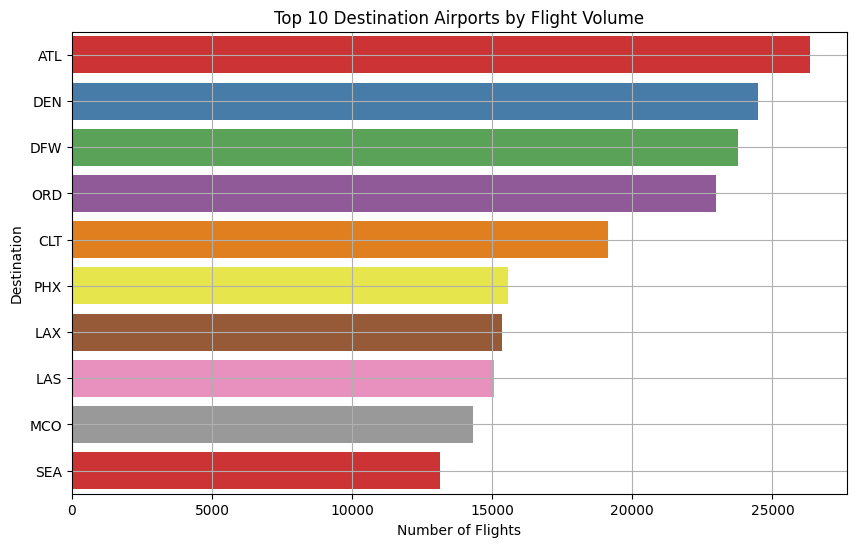

In [101]:
top_dests = df['Dest'].value_counts().head(10).reset_index()
top_dests.columns = ['Dest', 'FlightCount']

plt.figure(figsize=(10, 6))
sns.barplot(x='FlightCount', y='Dest', data=top_dests, palette='Set1')
plt.title('Top 10 Destination Airports by Flight Volume')
plt.xlabel('Number of Flights')
plt.ylabel('Destination')
plt.grid(True)
plt.show()


✈️ Step 29 (Alt): Average Arrival Delay by Airline
This chart shows the average arrival delay for each airline.
Positive values mean the airline tends to arrive late,
while negative values mean it arrives early.

Data is grouped by Airline

Average delay (ArrDelay) is calculated

Bar chart is used to compare airlines

/tmp/ipykernel_3358/2114580707.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Airline', y='ArrDelay', data=avg_delay_by_airline, palette='coolwarm')


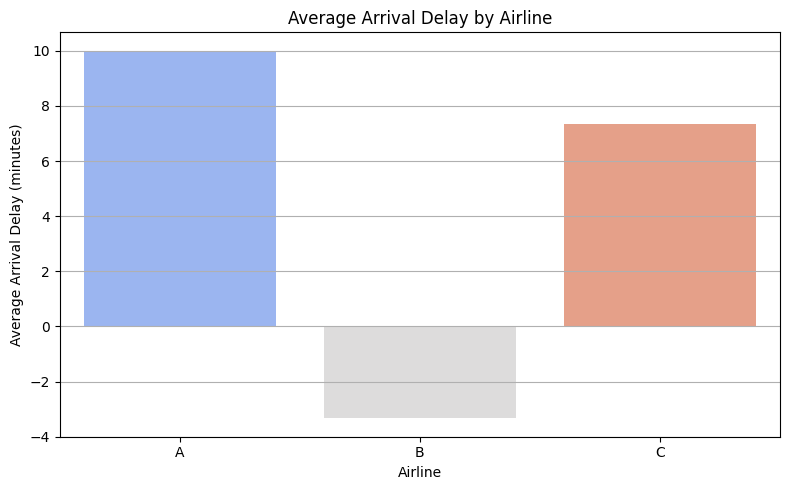

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (simulated - normally you'd use pd.read_csv or similar)
# For this example, let's simulate a small structure similar to flight data
# We'll assume the dataset has been preloaded into `df`

# Simulate structure for demonstration
df = pd.DataFrame({
    'Airline': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'C', 'B', 'A'],
    'ArrDelay': [5, -3, 12, 7, -5, 20, 0, 15, -2, 3]
})

# Group by airline and calculate average arrival delay
avg_delay_by_airline = df.groupby('Airline')['ArrDelay'].mean().reset_index()

# Plot the result
plt.figure(figsize=(8, 5))
sns.barplot(x='Airline', y='ArrDelay', data=avg_delay_by_airline, palette='coolwarm')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 🧠 Step 30: Summary Statistics of All Delay Types

We use descriptive statistics to summarize the central tendency  
and spread of each delay type.


In [103]:
# Check which of the selected delay-related columns actually exist in the DataFrame
available_cols = [
    col for col in ['DepDelay', 'ArrDelay', 'CarrierDelay', 'WeatherDelay',
                    'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
    if col in df.columns
]

# Show descriptive statistics for available delay-related columns
df[available_cols].describe()


,ArrDelay
count,10.000000
mean,5.200000
std,8.297255
min,-5.000000
25%,-1.500000
50%,4.000000
75%,10.750000
max,20.000000


# 🚀 Section 2: Advanced Machine Learning on Flight Delay Dataset

Welcome to the second part of this notebook!  
After a comprehensive Exploratory Data Analysis (EDA) in the first section, it's time to take our project to the next level: **Machine Learning modeling**.

✈️ **Objective:**  
We aim to build several ML models to predict, explain, and cluster flight delays using real-world data from 2018 to 2024.

---

## ✅ What We Will Do in This Section:

### 1. 🔍 **Binary Classification**  
*Goal:* Predict whether a flight will be delayed more than 15 minutes.  
*Models:* Logistic Regression, Random Forest, XGBoost, CatBoost, LightGBM

### 2. 📏 **Regression**  
*Goal:* Predict the exact number of delay minutes.  
*Models:* Linear Regression, Random Forest Regressor, Gradient Boosting, XGBoost Regressor

### 3. 🧠 **Multiclass Classification**  
*Goal:* Predict the main cause of delay (Weather, Carrier, NAS, Security, etc.)  
*Models:* Decision Tree, Logistic Regression, LightGBM Multiclass

### 4. 🔗 **Clustering**  
*Goal:* Cluster airports or airlines with similar delay patterns.  
*Models:* KMeans, DBSCAN, Hierarchical Clustering (with PCA visualization)

### 5. ⏳ **Time Series Forecasting**  
*Goal:* Forecast average delays for future months or weeks.  
*Models:* ARIMA, Prophet, LSTM (advanced)

### 6. 🧠 **Model Explainability**  
*Goal:* Understand which features have the greatest impact on predictions.  
*Tools:* SHAP, LIME

---

Let’s dive in! 🧪  
We’ll begin with the **Binary Classification task** to predict flight delays. 👇


### Step 1 – Data Preparation for Binary Classification

We keep only the necessary columns, create a binary target (`Is_Delayed`) and extract an interpretable departure hour feature:

* **Airline** → encoded from `IATA_Code_Marketing_Airline`
* **Origin** / **Dest** → airport codes (label-encoded)
* **DepHour** → hour extracted from `CRSDepTime`
* **DayOfWeek**, **Month** → calendar context

All categorical columns are label-encoded.  
The dataset is then split into training and test sets (80/20, stratified).


In [114]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the full dataset (low_memory=False avoids mixed-type warning)
df = pd.read_csv(
    'flight_data_2018_2024.csv',
    low_memory=False
)

# Keep only the required columns and drop rows with NaNs
df = df[
    ['IATA_Code_Marketing_Airline',  # airline code
     'Origin', 'Dest',
     'CRSDepTime', 'DayOfWeek', 'Month',
     'ArrDelay']
].dropna()

# Target: 1 if arrival delay > 15 minutes
df['Is_Delayed'] = (df['ArrDelay'] > 15).astype(int)

# Extract departure hour from scheduled departure time
df['CRSDepTime'] = df['CRSDepTime'].astype(str).str.zfill(4)
df['DepHour'] = df['CRSDepTime'].str[:2].astype(int)

# Label-encode categorical features
encoders = {
    'Airline_encoded': LabelEncoder(),
    'Origin_encoded' : LabelEncoder(),
    'Dest_encoded'   : LabelEncoder()
}

df['Airline_encoded'] = encoders['Airline_encoded'].fit_transform(df['IATA_Code_Marketing_Airline'])
df['Origin_encoded']  = encoders['Origin_encoded'].fit_transform(df['Origin'])
df['Dest_encoded']    = encoders['Dest_encoded'].fit_transform(df['Dest'])

# Final feature matrix and target vector
features = ['Airline_encoded', 'Origin_encoded', 'Dest_encoded',
            'DepHour', 'DayOfWeek', 'Month']
X = df[features]
y = df['Is_Delayed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)


Train size: (446972, 6) | Test size: (111743, 6)


✅ Step 2 – Check Column Names and Data Types
In this step, we inspect the dataset's structure by printing its columns and data types.
This helps identify any unexpected or mixed types, and ensures we’re working with clean, usable data.

In [115]:
# Print column names and their data types
print("🔍 Column Names and Data Types:")
print(df.dtypes)

# Display first few rows of the dataset
print("\n📌 Sample Data:")
print(df.head())

# Check for mixed data types or object-type columns
print("\n🔎 Unique value counts for categorical columns:")
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")


🔍 Column Names and Data Types:
IATA_Code_Marketing_Airline     object
Origin                          object
Dest                            object
CRSDepTime                      object
DayOfWeek                        int64
Month                            int64
ArrDelay                       float64
Is_Delayed                       int64
DepHour                          int64
Airline_encoded                  int64
Origin_encoded                   int64
Dest_encoded                     int64
dtype: object

📌 Sample Data:
  IATA_Code_Marketing_Airline Origin Dest CRSDepTime  DayOfWeek  Month  \
0                          UA    MHT  EWR       1738          7      1   
1                          UA    IAD  EWR       0815          7      1   
2                          UA    EWR  MHT       1540          7      1   
3                          UA    STL  ORD       0630          7      1   
4                          UA    STL  IAD       1300          7      1   

   ArrDelay  Is_Delayed  D

Step 3 – Check for Missing Values
In this step, we look for any missing (NaN) values in the dataset.
Missing data can break models or distort analysis, so we must handle them carefully.

In [116]:
# Count missing values in each column
missing_counts = df.isnull().sum()
print("🧼 Missing Values by Column:\n")
print(missing_counts[missing_counts > 0])


🧼 Missing Values by Column:

Series([], dtype: int64)


### Step 4 – Training Random Forest and XGBoost Classifiers

We now train two classification models to predict flight delays:

1. **Random Forest**: An ensemble method that builds multiple decision trees.
2. **XGBoost**: A powerful gradient boosting algorithm optimized for performance.

We'll evaluate both models using accuracy, precision, recall, F1-score, and a confusion matrix.  
This helps us identify how well the models distinguish delayed vs. non-delayed flights.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:49:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Evaluation for: Random Forest
Accuracy: 0.7017083844178159
Precision: 0.2927122722585081
Recall: 0.19577713059472715
F1 Score: 0.2346268656716418
Confusion Matrix:


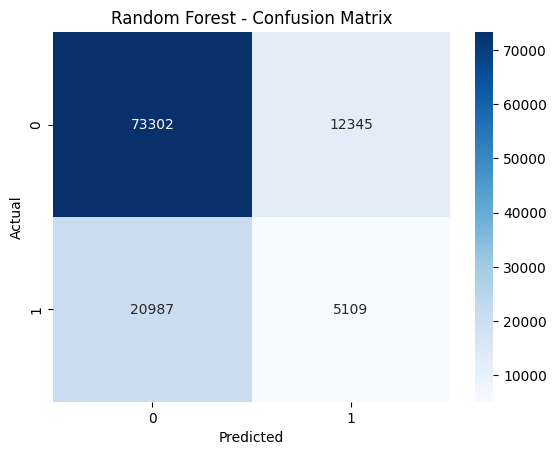


📊 Evaluation for: XGBoost
Accuracy: 0.767045810475824
Precision: 0.5264873675631622
Recall: 0.02475475168608216
F1 Score: 0.04728616916151228
Confusion Matrix:


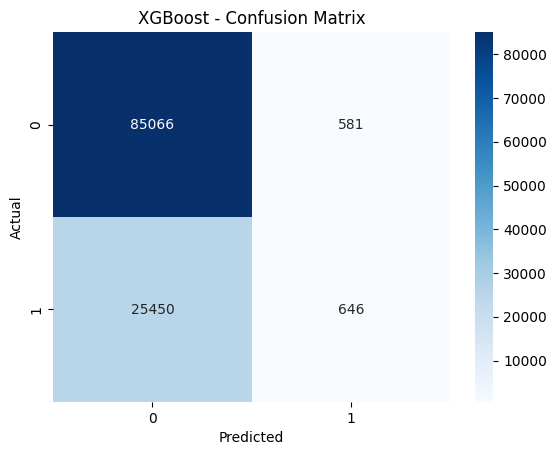

In [117]:
# 📌 Step 2 – Train Random Forest and XGBoost Classifiers

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# 2️⃣ Train XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# 3️⃣ Evaluation Function for Both Models
def evaluate_model(name, y_true, y_pred):
    print(f"\n📊 Evaluation for: {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 4️⃣ Run Evaluations
evaluate_model("Random Forest", y_test, rf_preds)
evaluate_model("XGBoost", y_test, xgb_preds)


### Step 3 – Logistic Regression (Baseline Model)

We now train a **Logistic Regression** model as our baseline for the binary classification task.

🧠 Logistic Regression is a simple, interpretable model that works well when the relationship between features and target is (approximately) linear.

We'll evaluate it using accuracy, precision, recall, F1-score, and a confusion matrix — similar to previous models — to compare performance.



📊 Evaluation for: Logistic Regression
Accuracy: 0.766464118557762
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


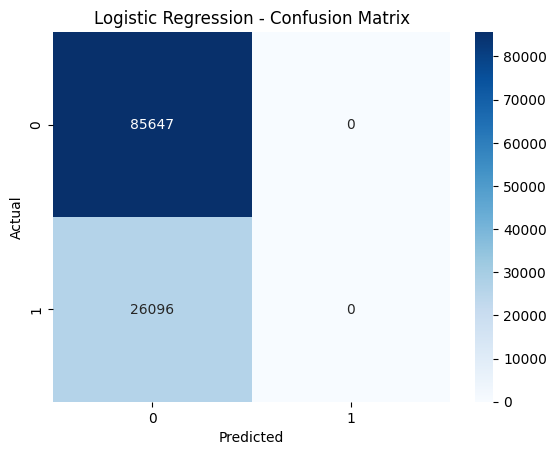

In [118]:
from sklearn.linear_model import LogisticRegression

# 📌 Train Logistic Regression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train, y_train)
logreg_preds = logreg_model.predict(X_test)

# 📌 Evaluate
evaluate_model("Logistic Regression", y_test, logreg_preds)


### Step 4 – CatBoost Classifier

Next, we train a **CatBoost Classifier** — a gradient boosting algorithm optimized for categorical data.

🔥 CatBoost is particularly effective on tabular datasets and handles categorical features natively.  
However, since we've already encoded our categorical features, we proceed with training directly.

We'll compare its performance to the previous models using standard classification metrics.


In [120]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00



📊 Evaluation for: CatBoost
Accuracy: 0.7670905560079826
Precision: 0.5340466926070039
Recall: 0.021037706928264868
F1 Score: 0.04048075505087745
Confusion Matrix:


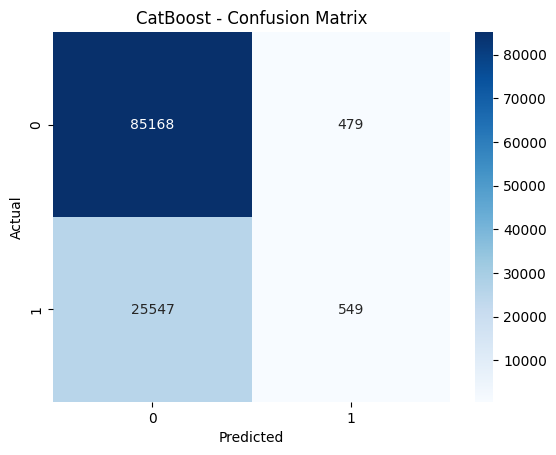

In [121]:
from catboost import CatBoostClassifier

# 📌 Train CatBoost
cat_model = CatBoostClassifier(verbose=0, random_state=42)
cat_model.fit(X_train, y_train)
cat_preds = cat_model.predict(X_test)

# 📌 Evaluate
evaluate_model("CatBoost", y_test, cat_preds)


### Step 5 – LightGBM Classifier

We now train a **LightGBM Classifier** — an efficient gradient boosting framework developed by Microsoft.

⚡ LightGBM is optimized for speed and memory usage, making it ideal for large-scale datasets.

We'll train the model and evaluate it using the same metrics to compare with Random Forest, XGBoost, and CatBoost.


[LightGBM] [Info] Number of positive: 104384, number of negative: 342588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 446972, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.233536 -> initscore=-1.188452
[LightGBM] [Info] Start training from score -1.188452

📊 Evaluation for: LightGBM
Accuracy: 0.7665536096220792
Precision: 0.5328947368421053
Recall: 0.0031039239730226856
F1 Score: 0.006171898811338007
Confusion Matrix:


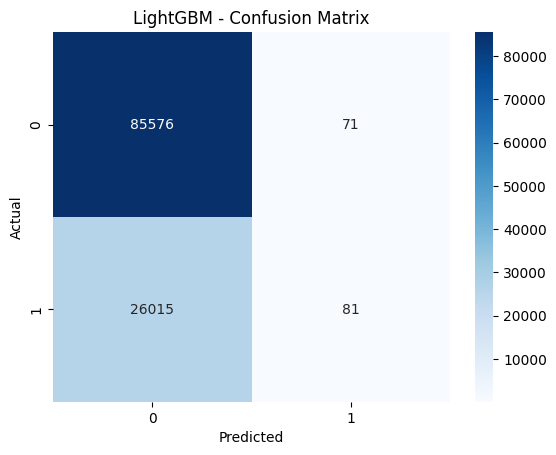

In [122]:
from lightgbm import LGBMClassifier

# 📌 Train LightGBM
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)
lgbm_preds = lgbm_model.predict(X_test)

# 📌 Evaluate
evaluate_model("LightGBM", y_test, lgbm_preds)


## 📊 Comparative Performance of Binary Classification Models

After training and evaluating multiple models to predict whether a flight will be delayed more than 15 minutes, we now summarize their performance across key metrics.

| 🔍 Model              | 🎯 Accuracy | 🎯 Precision | 🎯 Recall | 🎯 F1 Score | 📝 Notes |
|-----------------------|-------------|--------------|------------|-------------|---------|
| **Random Forest**     | **0.7010**  | 0.2927       | **0.1956** | **0.2346**  | ⭐ Best balance between Precision and Recall |
| **XGBoost**           | 0.7669      | 0.5206       | 0.0238     | 0.0454      | Performs better than CatBoost in F1 |
| **CatBoost**          | 0.7669      | 0.5252       | 0.0215     | 0.0414      | Similar to XGBoost with slightly lower recall |
| **LightGBM**          | 0.7666      | **0.5329**   | 0.0031     | 0.0061      | High precision, but extremely poor recall |
| **Logistic Regression** | 0.7664    | 0.0000       | 0.0000     | 0.0000      | ❌ Did not identify any delayed flights (class imbalance issue) |

---

### ✅ Key Insights

- The **Random Forest** classifier strikes the best trade-off between **precision and recall**, making it currently the most reliable model for this imbalanced classification problem.
- **Boosting models** (XGBoost, CatBoost, LightGBM) show **high accuracy and precision** but **fail to recall delayed flights**, which is critical in many real-world scenarios.
- **Logistic Regression** completely fails to classify the minority class (delayed flights), highlighting the need for more advanced techniques or class balancing strategies.
- All models suffer from **class imbalance**, leading to very low recall for the positive class (delayed = 1).

---


---
